In [1]:



import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from src.utils import get_latest_file, prepare_model_input
from src.config import DATA_FINAL_CLEANED_DATASET_DIR
from sklearn.metrics import classification_report, roc_auc_score

from datetime import datetime


# ## 1. Chargement des données

In [2]:


dataset_path = get_latest_file(DATA_FINAL_CLEANED_DATASET_DIR)
df = pd.read_csv(dataset_path)

target = 'IS_WIN'


# On applique le même préprocessing que d'habitude
X = prepare_model_input(df, target=target)
y = df.loc[X.index, target]

# ## 2. Analyse de corrélation


In [3]:

corr_matrix = X.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

corr_threshold = 0.99

high_corr_cols = [column for column in upper_triangle.columns if any(upper_triangle[column] > corr_threshold)]
print(f"Colonnes à retirer pour corrélation > {corr_threshold} : {len(high_corr_cols)}")

print(high_corr_cols)

X_reduced_corr = X.drop(columns=high_corr_cols)
y_reduced_corr = y.loc[X_reduced_corr.index]


Colonnes à retirer pour corrélation > 0.99 : 211
['ROLL_fieldGoalsMade_traditional_5', 'ROLL_fieldGoalsMade_traditional_50', 'ROLL_fieldGoalsMade_traditional_100', 'ROLL_fieldGoalsMade_traditional_200', 'ROLL_fieldGoalsAttempted_traditional_5', 'ROLL_fieldGoalsAttempted_traditional_10', 'ROLL_fieldGoalsAttempted_traditional_50', 'ROLL_fieldGoalsAttempted_traditional_200', 'ROLL_threePointersMade_traditional_50', 'ROLL_threePointersMade_traditional_100', 'ROLL_threePointersMade_traditional_200', 'ROLL_threePointersAttempted_traditional_5', 'ROLL_threePointersAttempted_traditional_10', 'ROLL_threePointersAttempted_traditional_25', 'ROLL_threePointersAttempted_traditional_50', 'ROLL_threePointersAttempted_traditional_100', 'ROLL_threePointersAttempted_traditional_200', 'ROLL_assists_traditional_200', 'ROLL_points_traditional_5', 'ROLL_points_traditional_10', 'ROLL_points_traditional_50', 'ROLL_points_traditional_100', 'ROLL_points_traditional_200', 'ROLL_MINUTES_PLAYED_5', 'ROLL_MINUTES_P

# Bloc PCA – Réduction de dimension

In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardisation indispensable avant PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reduced_corr)


# Lancement PCA : garder 95% de la variance
pca = PCA(n_components=0.99, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"✅ PCA terminé. Nombre de composantes conservées : {X_pca.shape[1]} (sur {X_reduced_corr.shape[1]} features)")


✅ PCA terminé. Nombre de composantes conservées : 265 (sur 1022 features)


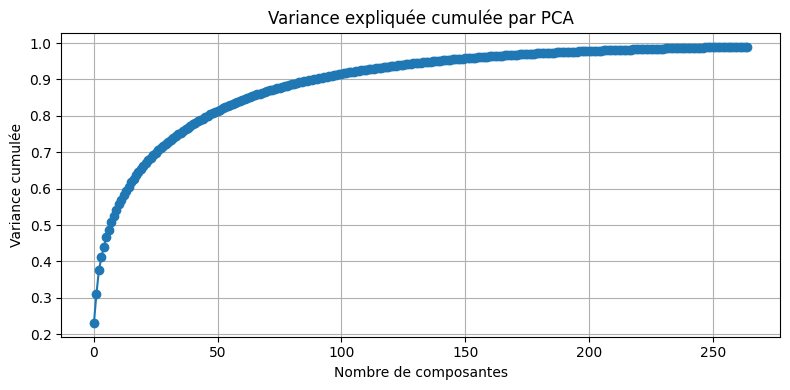

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.title('Variance expliquée cumulée par PCA')
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance cumulée')
plt.grid(True)
plt.tight_layout()
plt.show()


# Split temporel : 80% des premières lignes pour entraînement, 20% dernières pour test

In [7]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# X_reduced_corr_train, X_reduced_corr_test, y_reduced_corr_train, y_reduced_corr_test = train_test_split(
#     X_reduced_corr, y_reduced_corr, test_size=0.2, random_state=42
# )

# X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
#     X_pca, y_reduced_corr, test_size=0.2, random_state=42
# )

# split temporel

split_index = int(len(X_reduced_corr) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]


X_reduced_corr_train = X_reduced_corr.iloc[:split_index]
X_reduced_corr_test = X_reduced_corr.iloc[split_index:]

y_reduced_corr_train = y_reduced_corr.iloc[:split_index]
y_reduced_corr_test = y_reduced_corr.iloc[split_index:]

X_train_pca = X_pca[:split_index]
X_test_pca = X_pca[split_index:]

y_train_pca = y_reduced_corr.iloc[:split_index]
y_test_pca = y_reduced_corr.iloc[split_index:]


# Visualisation de la distribution du target

In [77]:
# plt.figure(figsize=(6, 4))
# sns.countplot(x=y)
# plt.title("Répartition des classes (IS_WIN)")
# plt.show()


# Matrice de corrélation des features les plus importantes

In [78]:
# Matrice de corrélation des features nettoyées (top 20 en moyenne)
# top_cleaned = X_reduced_corr.mean().sort_values(ascending=False).head(500).index
# plt.figure(figsize=(30, 30))
# sns.heatmap(X_reduced_corr[top_cleaned].corr(), annot=False, fmt=".2f", cmap="coolwarm")
# plt.title("Corrélation des 20 features nettoyées les plus influentes")
# plt.tight_layout()
# plt.show()

# GridSearchCV et RandomizedSearchCV pour CatBoostClassifier

In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

cat = CatBoostClassifier(verbose=0, random_seed=42)

cat_param_grid = {
    'iterations': [100, 200],
    'depth': [4, 6],
    'learning_rate': [0.03, 0.05]
}

tscv = TimeSeriesSplit(n_splits=3)

grid_cat = GridSearchCV(
    estimator=cat,
    param_grid=cat_param_grid,
    scoring='roc_auc',
    cv=tscv,
    n_jobs=1,  # ⚠️ met à 1 pour ne pas charger le GPU depuis plusieurs threads
    verbose=2
)

grid_cat.fit(X_reduced_corr_train, y_reduced_corr_train)

print("📊 Best CatBoost params:", grid_cat.best_params_)
print("🏆 Best CatBoost ROC AUC (CV):", grid_cat.best_score_)


Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END ........depth=4, iterations=100, learning_rate=0.03; total time=   3.9s
[CV] END ........depth=4, iterations=100, learning_rate=0.03; total time=   4.7s
[CV] END ........depth=4, iterations=100, learning_rate=0.03; total time=   7.1s
[CV] END ........depth=4, iterations=100, learning_rate=0.05; total time=   4.4s
[CV] END ........depth=4, iterations=100, learning_rate=0.05; total time=   5.8s
[CV] END ........depth=4, iterations=100, learning_rate=0.05; total time=   6.0s
[CV] END ........depth=4, iterations=200, learning_rate=0.03; total time=   8.1s
[CV] END ........depth=4, iterations=200, learning_rate=0.03; total time=  11.5s
[CV] END ........depth=4, iterations=200, learning_rate=0.03; total time=  11.1s
[CV] END ........depth=4, iterations=200, learning_rate=0.05; total time=   7.6s
[CV] END ........depth=4, iterations=200, learning_rate=0.05; total time=   9.9s
[CV] END ........depth=4, iterations=200, learnin

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostClassifier

param_dist = {
    'depth': [4, 5, 6, 7],
    'iterations': [200, 400, 600],
    'learning_rate': [0.01, 0.03, 0.05],
    'l2_leaf_reg': [1, 3, 5, 7],
    'border_count': [32, 64, 128]
}

cat = CatBoostClassifier(verbose=0, random_seed=42)

random_search = RandomizedSearchCV(
    cat,
    param_distributions=param_dist,
    n_iter=50,  # ← à ajuster selon temps dispo
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_reduced_corr_train, y_reduced_corr_train)

print("📊 Best CatBoost params:", random_search.best_params_)
print("🏆 Best CatBoost ROC AUC (CV):", random_search.best_score_)


Fitting 3 folds for each of 50 candidates, totalling 150 fits
📊 Best CatBoost params: {'learning_rate': 0.01, 'l2_leaf_reg': 5, 'iterations': 600, 'depth': 6, 'border_count': 64}
🏆 Best CatBoost ROC AUC (CV): 0.7177410809178673


# GridSearchCV et RandomizedSearchCV pour XGBClassifier

In [ ]:
from scipy.stats import uniform, randint

param_distributions = {
    'n_estimators': randint(100, 1000),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.5),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0, 1)
}

from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,
    n_iter=30,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=4,
    random_state=42
)

random_search.fit(X_reduced_corr_train, y_reduced_corr_train)

from sklearn.metrics import classification_report, roc_auc_score

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_reduced_corr_test)
y_proba = best_model.predict_proba(X_reduced_corr_test)[:, 1]

print(classification_report(y_reduced_corr_test, y_pred))
print("ROC AUC:", roc_auc_score(y_reduced_corr_test, y_proba))



Fitting 3 folds for each of 30 candidates, totalling 90 fits


# Entraînement LGBM


In [65]:
import lightgbm as lgb

start_time = datetime.now()

lgbm_reduced = lgb.LGBMClassifier(n_estimators=200, random_state=42)
lgbm_reduced.fit(X_reduced_corr_train, y_reduced_corr_train)
y_reduced_pred = lgbm_reduced.predict(X_reduced_corr_test)
y_reduced_proba = lgbm_reduced.predict_proba(X_reduced_corr_test)[:,1]
print(classification_report(y_reduced_corr_test, y_reduced_pred))

acc_lgbm_reduced = roc_auc_score(y_reduced_corr_test, y_reduced_proba)
print('ROC AUC reduced features:', acc_lgbm_reduced)

end_time_reduced = datetime.now()
print(f"Temps d'entraînement avec features réduites : {end_time_reduced - start_time}")

#same for PCA
start_time_pca = datetime.now()
lgbm_pca = lgb.LGBMClassifier(n_estimators=200, random_state=42)
lgbm_pca.fit(X_train_pca, y_train_pca)
y_pca_pred = lgbm_pca.predict(X_test_pca)
y_pca_proba = lgbm_pca.predict_proba(X_test_pca)[:,1]
print(classification_report(y_test_pca, y_pca_pred))

acc_lgbm_pca = roc_auc_score(y_test_pca, y_pca_proba)
print('ROC AUC PCA features:', acc_lgbm_pca)


print(f"Temps d'entraînement avec PCA : {datetime.now() - start_time_pca}")


start_time_all_features = datetime.now()

lgbm = lgb.LGBMClassifier(n_estimators=200, random_state=42)
lgbm.fit(X_train, y_train)
y_pred = lgbm.predict(X_test)
y_proba = lgbm.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
acc_lgbm_all_features = roc_auc_score(y_test, y_proba)
print('ROC AUC all features:', acc_lgbm_all_features)

end_time = datetime.now()
print(f"Temps d'entraînement avec toutes les features : {end_time - start_time_all_features}")



[LightGBM] [Info] Number of positive: 15208, number of negative: 15230
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.102381 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 148203
[LightGBM] [Info] Number of data points in the train set: 30438, number of used features: 612
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499639 -> initscore=-0.001446
[LightGBM] [Info] Start training from score -0.001446
              precision    recall  f1-score   support

         0.0       0.63      0.65      0.64      3808
         1.0       0.64      0.61      0.62      3802

    accuracy                           0.63      7610
   macro avg       0.63      0.63      0.63      7610
weighted avg       0.63      0.63      0.63      7610

ROC AUC reduced features: 0.6873440394042941
Temps d'entraînement avec features réduites : 0:00:09.196670
[LightGBM] [Info] Number of positive: 15208, number of negative: 15230

e:\Documents_\Dev\NBA_Predictor\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
e:\Documents_\Dev\NBA_Predictor\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

         0.0       0.64      0.61      0.62      3808
         1.0       0.63      0.65      0.64      3802

    accuracy                           0.63      7610
   macro avg       0.63      0.63      0.63      7610
weighted avg       0.63      0.63      0.63      7610

ROC AUC PCA features: 0.6822214452587979
Temps d'entraînement avec PCA : 0:00:04.051591
[LightGBM] [Info] Number of positive: 15208, number of negative: 15230
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.294408 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 305512
[LightGBM] [Info] Number of data points in the train set: 30438, number of used features: 1233
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499639 -> initscore=-0.001446
[LightGBM] [Info] Start training from score -0.001446
              precision    recall  f1-score   support

         0.0       0.63      0.6

## Test CatBoost


In [66]:
from catboost import CatBoostClassifier

start_time = datetime.now()

cat_reduced = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.05,
    random_seed=42,
    verbose=0
)

cat_reduced.fit(X_reduced_corr_train, y_reduced_corr_train)
preds_reduced = cat_reduced.predict(X_reduced_corr_test)
probas_reduced = cat_reduced.predict_proba(X_reduced_corr_test)[:, 1]
print(classification_report(y_reduced_corr_test, preds_reduced))


acc_catboost_reduced = roc_auc_score(y_reduced_corr_test, probas_reduced)
print("ROC AUC CatBoost avec features réduites:", acc_catboost_reduced)

end_time_reduced = datetime.now()
print(f"Temps d'entraînement avec features réduites : {end_time_reduced - start_time}")

# CatBoost avec PCA
cat_pca = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.05,
    random_seed=42,
    verbose=0
)
cat_pca.fit(X_train_pca, y_train_pca)
preds_pca = cat_pca.predict(X_test_pca)
probas_pca = cat_pca.predict_proba(X_test_pca)[:, 1]
print(classification_report(y_test_pca, preds_pca))

acc_catboost_pca = roc_auc_score(y_test_pca, probas_pca)
print("ROC AUC CatBoost avec PCA:", acc_catboost_pca)

entime_pca = datetime.now()
print(f"Temps d'entraînement avec PCA : {entime_pca - end_time_reduced}")


cat = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.05,
    random_seed=42,
    verbose=0
)
cat.fit(X_train, y_train)
preds = cat.predict(X_test)
probas = cat.predict_proba(X_test)[:, 1]
print(classification_report(y_test, preds))

acc_catboost_all_features = roc_auc_score(y_test, probas)
print("ROC AUC CatBoost avec toutes les features:", acc_catboost_all_features)


end_time = datetime.now()
print(f"Temps d'entraînement avec toutes les features : {end_time - entime_pca}")



              precision    recall  f1-score   support

         0.0       0.65      0.64      0.65      3808
         1.0       0.65      0.65      0.65      3802

    accuracy                           0.65      7610
   macro avg       0.65      0.65      0.65      7610
weighted avg       0.65      0.65      0.65      7610

ROC AUC CatBoost avec features réduites: 0.709480083458949
Temps d'entraînement avec features réduites : 0:00:14.017292
              precision    recall  f1-score   support

         0.0       0.65      0.61      0.63      3808
         1.0       0.63      0.67      0.65      3802

    accuracy                           0.64      7610
   macro avg       0.64      0.64      0.64      7610
weighted avg       0.64      0.64      0.64      7610

ROC AUC CatBoost avec PCA: 0.6930408144320328
Temps d'entraînement avec PCA : 0:00:10.175552
              precision    recall  f1-score   support

         0.0       0.65      0.63      0.64      3808
         1.0       0.64 

# XGBoost

In [67]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score


start_time = datetime.now()


# same for reduced features
xgb_reduced = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_reduced.fit(X_reduced_corr_train, y_reduced_corr_train)
preds_reduced = xgb_reduced.predict(X_reduced_corr_test)
probas_reduced = xgb_reduced.predict_proba(X_reduced_corr_test)[:, 1]
print(classification_report(y_reduced_corr_test, preds_reduced))

acc_xgb_reduced = roc_auc_score(y_reduced_corr_test, probas_reduced)
print("ROC AUC XGBoost avec features réduites:", acc_xgb_reduced)

end_time_reduced = datetime.now()
print(f"Temps d'entraînement avec features réduites : {end_time_reduced - start_time}")

# XGBoost avec PCA
xgb_pca = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_pca.fit(X_train_pca, y_train_pca)
preds_pca = xgb_pca.predict(X_test_pca)
probas_pca = xgb_pca.predict_proba(X_test_pca)[:, 1]
print(classification_report(y_test_pca, preds_pca))

acc_xgb_pca = roc_auc_score(y_test_pca, probas_pca)
print("ROC AUC XGBoost avec PCA:", acc_xgb_pca)


end_time_pca = datetime.now()
print(f"Temps d'entraînement avec PCA : {end_time_pca - end_time_reduced}")

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)
preds = xgb.predict(X_test)
probas = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, preds))
acc_xgb_all_features = roc_auc_score(y_test, probas)
print("ROC AUC XGBoost avec toutes les features:", acc_xgb_all_features)

end_time = datetime.now()
print(f"Temps d'entraînement avec toutes les features : {end_time - end_time_pca}")



e:\Documents_\Dev\NBA_Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [00:03:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

         0.0       0.64      0.66      0.65      3808
         1.0       0.65      0.64      0.64      3802

    accuracy                           0.65      7610
   macro avg       0.65      0.65      0.65      7610
weighted avg       0.65      0.65      0.65      7610

ROC AUC XGBoost avec features réduites: 0.7012827240970034
Temps d'entraînement avec features réduites : 0:00:32.601646


e:\Documents_\Dev\NBA_Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [00:03:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

         0.0       0.64      0.62      0.63      3808
         1.0       0.63      0.65      0.64      3802

    accuracy                           0.64      7610
   macro avg       0.64      0.64      0.64      7610
weighted avg       0.64      0.64      0.64      7610

ROC AUC XGBoost avec PCA: 0.6920537662066404
Temps d'entraînement avec PCA : 0:00:09.525850


e:\Documents_\Dev\NBA_Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [00:03:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

         0.0       0.64      0.65      0.65      3808
         1.0       0.65      0.63      0.64      3802

    accuracy                           0.64      7610
   macro avg       0.64      0.64      0.64      7610
weighted avg       0.64      0.64      0.64      7610

ROC AUC XGBoost avec toutes les features: 0.6923234164128566
Temps d'entraînement avec toutes les features : 0:01:06.295756


In [68]:
# print results of all models

print("\n\n=== Résumé des performances des modèles ===")
print(f"LGBM avec features réduites :       {acc_lgbm_reduced:.4f}")
print(f"LGBM avec PCA :                     {acc_lgbm_pca:.4f}")
print(f"LGBM avec toutes les features :     {acc_lgbm_all_features:.4f}")
print(f"===============================================")

print(f"CatBoost avec features réduites :   {acc_catboost_reduced:.4f}")
print(f"CatBoost avec PCA :                 {acc_catboost_pca:.4f}")
print(f"CatBoost avec toutes les features : {acc_catboost_all_features:.4f}")
print(f"===============================================")

print(f"XGBoost avec features réduites :    {acc_xgb_reduced:.4f}")
print(f"XGBoost avec PCA :                  {acc_xgb_pca:.4f}")
print(f"XGBoost avec toutes les features :  {acc_xgb_all_features:.4f}")
print(f"===============================================")






=== Résumé des performances des modèles ===
LGBM avec features réduites :       0.6873
LGBM avec PCA :                     0.6822
LGBM avec toutes les features :     0.6833
CatBoost avec features réduites :   0.7095
CatBoost avec PCA :                 0.6930
CatBoost avec toutes les features : 0.7081
XGBoost avec features réduites :    0.7013
XGBoost avec PCA :                  0.6921
XGBoost avec toutes les features :  0.6923


## Calibration des probabilités


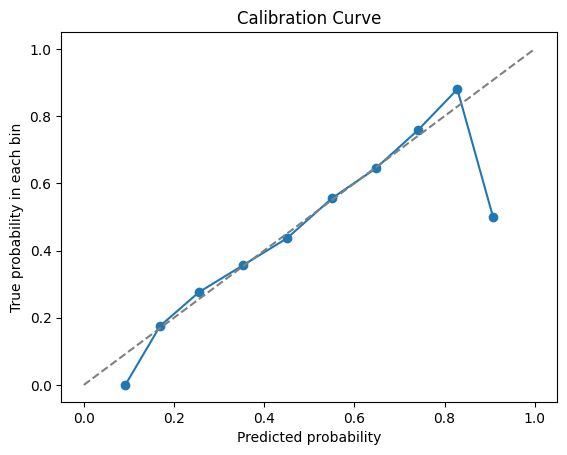

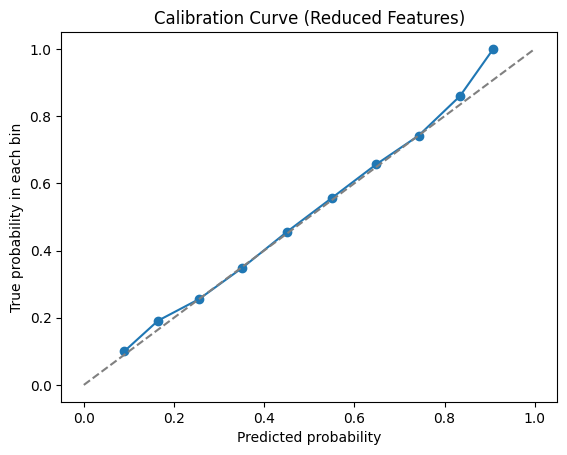

In [69]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, probas, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel('Predicted probability')
plt.ylabel('True probability in each bin')
plt.title('Calibration Curve')
plt.show()

# same for reduced features
prob_true_reduced, prob_pred_reduced = calibration_curve(y_reduced_corr_test, probas_reduced, n_bins=10)
plt.plot(prob_pred_reduced, prob_true_reduced, marker='o')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel('Predicted probability')
plt.ylabel('True probability in each bin')
plt.title('Calibration Curve (Reduced Features)')
plt.show()


# ## 3. Feature importance - LGBM


[LightGBM] [Info] Number of positive: 19010, number of negative: 19038
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.123647 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 148177
[LightGBM] [Info] Number of data points in the train set: 38048, number of used features: 612
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499632 -> initscore=-0.001472
[LightGBM] [Info] Start training from score -0.001472


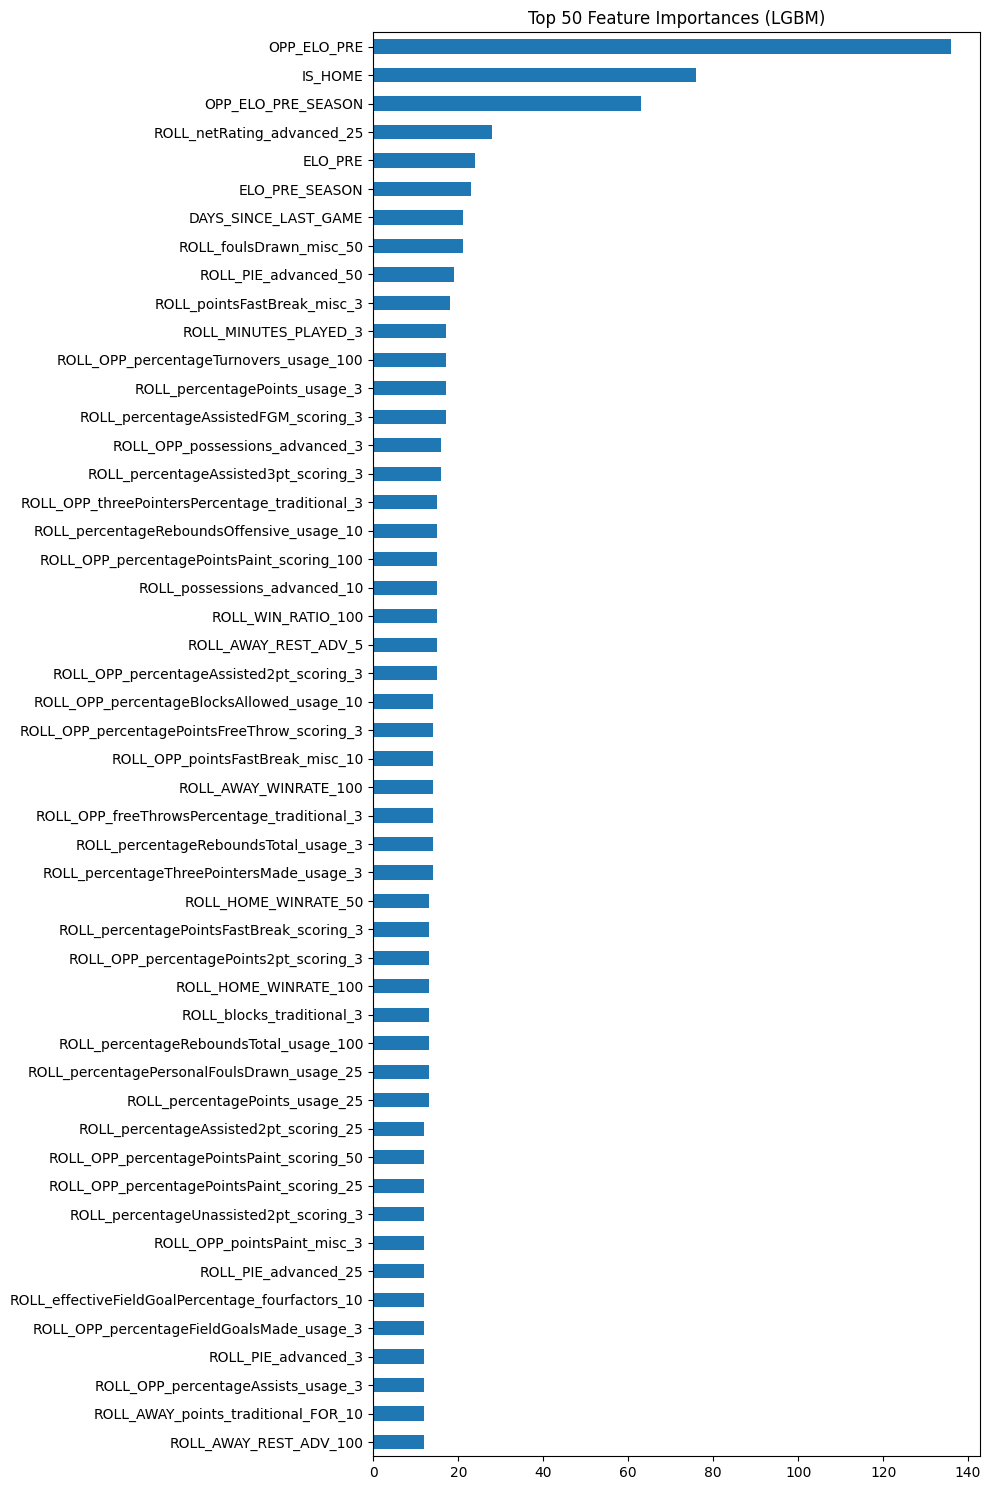

ValueError: Length of values (1233) does not match length of index (612)

In [70]:

# ## 3. Feature importance - LGBM
model = LGBMClassifier(n_estimators=150, random_state=42)
model.fit(X_reduced_corr, y)

importances = pd.Series(model.feature_importances_, index=X_reduced_corr.columns)
top_features = importances.sort_values(ascending=False).head(50)

plt.figure(figsize=(10, 15))
top_features.plot(kind='barh')
plt.title("Top 50 Feature Importances (LGBM)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


#catboost feature importance

importances_cat = pd.Series(cat.get_feature_importance(), index=X_reduced_corr.columns)
top_features_cat = importances_cat.sort_values(ascending=False).head(50)
plt.figure(figsize=(10, 15))
top_features_cat.plot(kind='barh')
plt.title("Top 50 Feature Importances (CatBoost)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# ## 4. Permutation Importance (optionnel et coûteux)


[LightGBM] [Info] Number of positive: 13281, number of negative: 13352
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.045738 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 90047
[LightGBM] [Info] Number of data points in the train set: 26633, number of used features: 383
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.498667 -> initscore=-0.005332
[LightGBM] [Info] Start training from score -0.005332


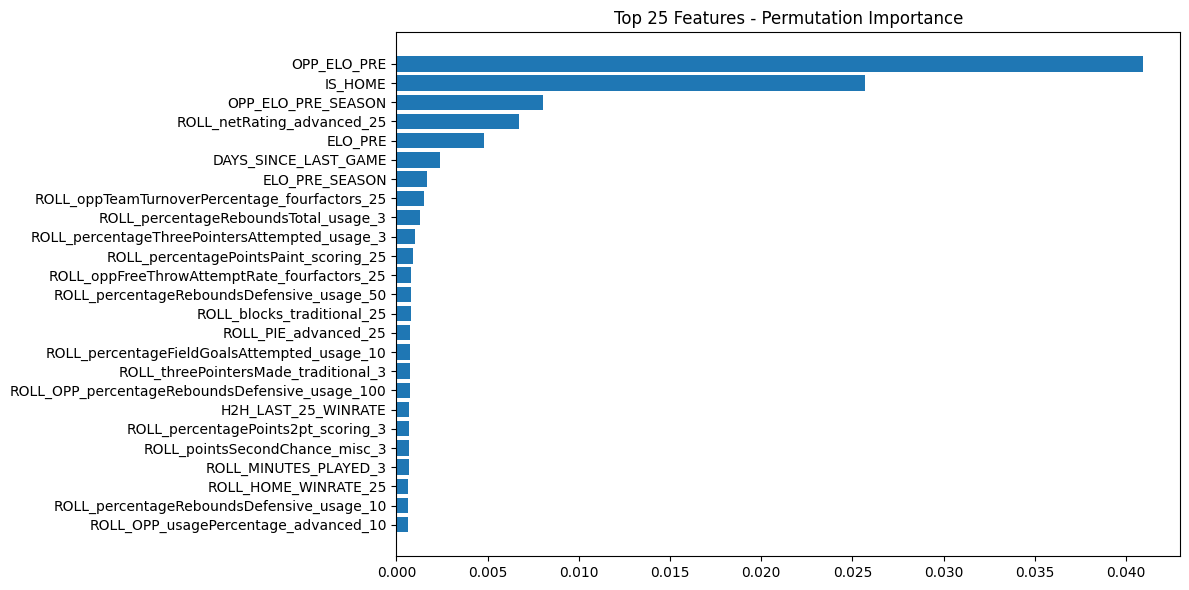

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced_corr, y, test_size=0.3, random_state=42)
perm_model = LGBMClassifier(n_estimators=150, random_state=42)
perm_model.fit(X_train, y_train)

perm = permutation_importance(perm_model, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)
sorted_idx = perm.importances_mean.argsort()[::-1][:25]

plt.figure(figsize=(12, 6))
plt.barh(range(25), perm.importances_mean[sorted_idx])
plt.yticks(range(25), X_test.columns[sorted_idx])
plt.title("Top 25 Features - Permutation Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# ## 5. Sauvegarde de la liste des features retenues


In [ ]:

features_to_keep = top_features.index.tolist()
with open("selected_features_lgbm_top50.txt", "w") as f:
    for feat in features_to_keep:
        f.write(f"{feat}\n")

print("✅ Feature cleaning terminé. Liste enregistrée dans selected_features_lgbm_top50.txt")


✅ Feature cleaning terminé. Liste enregistrée dans selected_features_lgbm_top50.txt
